# CO543: Image Processing - Lab 5 (2025)

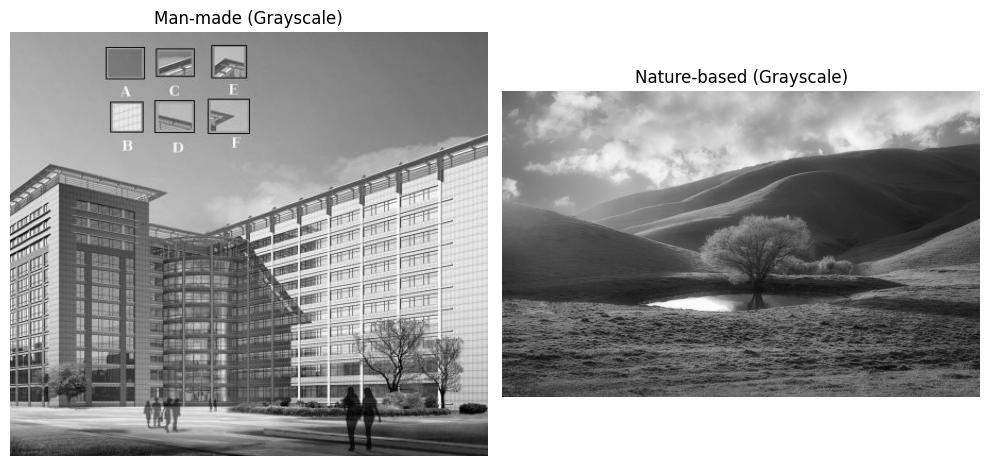

In [20]:
#Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# For displaying images nicely
def show(img, title='', cmap='gray'):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

# Load images & convert to grayscale
img1 = cv2.imread('man_made.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

img2 = cv2.imread('nature_based.jpg')
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.title('Man-made (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap='gray')
plt.title('Nature-based (Grayscale)')
plt.axis('off')

plt.tight_layout()
plt.show()

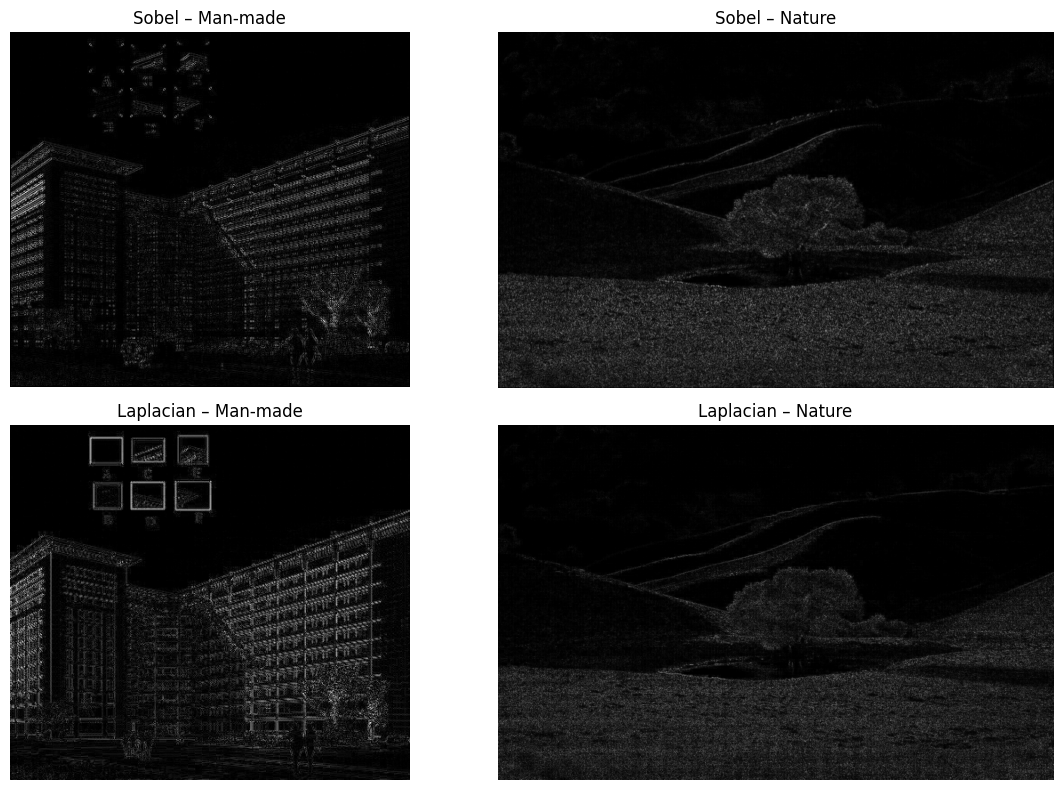

In [21]:
#Task 1 — Detect Edges Using Gradient Operators
#(Sobel & Laplacian)

# Sobel operator
sobel1 = cv2.Sobel(gray1, cv2.CV_64F, 1, 1, ksize=3)
sobel2 = cv2.Sobel(gray2, cv2.CV_64F, 1, 1, ksize=3)

# Laplacian operator
lap1 = cv2.Laplacian(gray1, cv2.CV_64F)
lap2 = cv2.Laplacian(gray2, cv2.CV_64F)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(np.abs(sobel1), cmap='gray')
plt.title('Sobel – Man-made')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(np.abs(sobel2), cmap='gray')
plt.title('Sobel – Nature')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(np.abs(lap1), cmap='gray')
plt.title('Laplacian – Man-made')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(np.abs(lap2), cmap='gray')
plt.title('Laplacian – Nature')
plt.axis('off')

plt.tight_layout()
plt.show()

***Comparing the smoothness and sensitivity of both filters and explaining what kind of
edges each emphasizes:***

The Sobel operator produces smoother and direction-aware edges by computing first-order intensity gradients. It highlights dominant structural edges clearly in the man-made image while producing softer, fragmented edges in the nature-based image. The Laplacian operator, based on second-order derivatives, emphasizes rapid intensity changes and produces stronger responses around edges, often on both sides. While Sobel is less sensitive to noise, Laplacian detects finer details but is more noise-sensitive, especially in textured natural scenes.


---


***More to think: Why does the Laplacian respond strongly at both sides of an edge while Sobel
gives direction?***

The Laplacian computes the second derivative, which changes sign across an edge, resulting in strong responses on both sides. Sobel computes the first derivative, providing directional information about intensity changes.

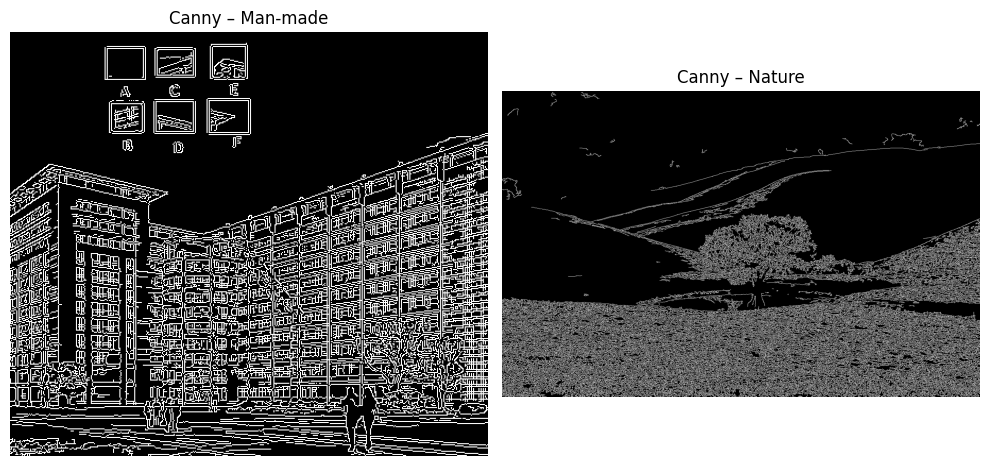

In [22]:
#Task 2 — Detect Clean Boundaries with Canny

edges1 = cv2.Canny(gray1, 50, 150)
edges2 = cv2.Canny(gray2, 50, 150)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(edges1, cmap='gray')
plt.title('Canny – Man-made')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges2, cmap='gray')
plt.title('Canny – Nature')
plt.axis('off')

plt.tight_layout()
plt.show()

***Why Canny edges appear thinner and cleaner than gradient outputs and
how its thresholds affect noise suppression?***

Canny edge detection produces thinner and cleaner edges compared to gradient-based methods. This is because it applies Gaussian smoothing, non-maximum suppression, and double thresholding. The man-made image shows continuous, well-defined edges, while the nature-based image contains more broken edges due to irregular textures. Adjusting threshold values controls noise suppression and edge sensitivity.


---

***More to think: How does hysteresis thresholding assist in avoiding broken edges?***

Hysteresis thresholding preserves weak edge pixels only if they are connected to strong edges, ensuring edge continuity while suppressing isolated noise responses.

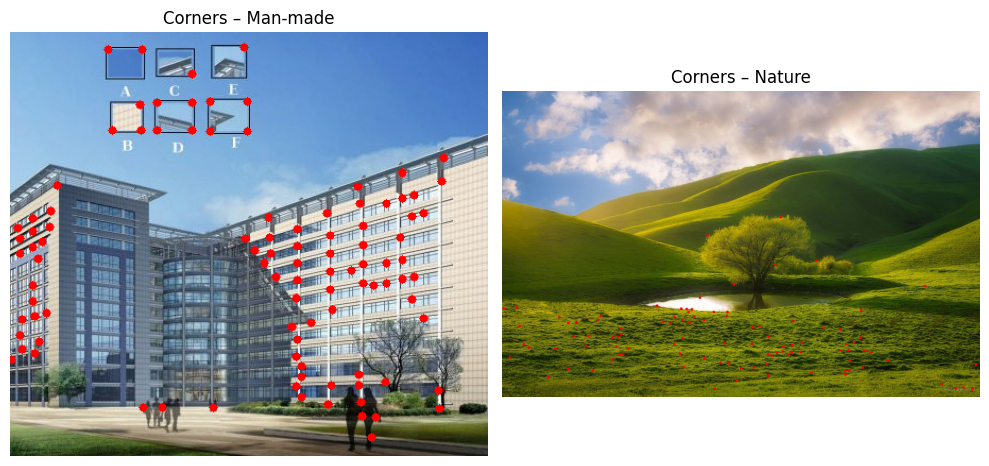

In [23]:
#Task 3 — Locate Corner Features

corners1 = cv2.goodFeaturesToTrack(gray1, 100, 0.01, 10)
corners2 = cv2.goodFeaturesToTrack(gray2, 100, 0.01, 10)

corner_img1 = img1.copy()
corner_img2 = img2.copy()

if corners1 is not None:
    for c in corners1:
        x, y = c.ravel()
        cv2.circle(corner_img1, (int(x), int(y)), 4, (0,0,255), -1)

if corners2 is not None:
    for c in corners2:
        x, y = c.ravel()
        cv2.circle(corner_img2, (int(x), int(y)), 4, (0,0,255), -1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(corner_img1, cv2.COLOR_BGR2RGB))
plt.title('Corners – Man-made')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(corner_img2, cv2.COLOR_BGR2RGB))
plt.title('Corners – Nature')
plt.axis('off')

plt.tight_layout()
plt.show()

***Discuss which points remain stable under small viewpoint or lighting changes and why corners
are valuable in matching and tracking***

Corners detected in the man-made image are more stable and distinct due to sharp intensity variations at structural junctions. In contrast, the nature-based image produces fewer stable corners because of smoother and repetitive textures. Corners are valuable for image matching and tracking since they remain identifiable under small changes in viewpoint and illumination.


---

***More to think: Why are corners more distinctive than straight edges for object recognition?***

Edges vary significantly along their length and provide limited uniqueness, whereas corners exhibit intensity changes in multiple directions, making them more reliable and distinctive features.

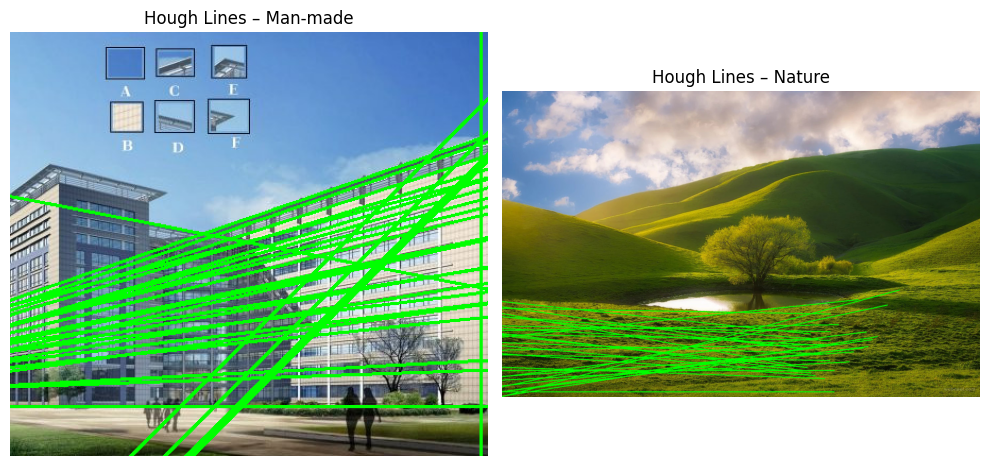

In [24]:
#Task 4 — Extract Dominant Lines

lines1 = cv2.HoughLines(edges1, 1, np.pi/180, 150)
lines2 = cv2.HoughLines(edges2, 1, np.pi/180, 150)

line_img1 = img1.copy()
line_img2 = img2.copy()

def draw_lines(img, lines, max_lines =30):
    if lines is not None:
        for i in range(min(len(lines), max_lines)):
            rho, theta = lines[i][0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(img, (x1,y1), (x2,y2), (0,255,0), 2)

draw_lines(line_img1, lines1)
draw_lines(line_img2, lines2)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(line_img1, cv2.COLOR_BGR2RGB))
plt.title('Hough Lines – Man-made')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(line_img2, cv2.COLOR_BGR2RGB))
plt.title('Hough Lines – Nature')
plt.axis('off')

plt.tight_layout()
plt.show()

***How detected lines represent man-made structure and how changing the vote threshold alters results?***

* The Hough Transform successfully detects strong straight lines in the man-made image, corresponding to walls, roofs, and structural boundaries. The nature-based image produces fewer meaningful lines due to the absence of long straight edges.
* Increasing the vote threshold reduces false detections but may miss weaker structural lines.


---

***More to think: Could detecting too many edges or lines make interpretation harder instead of
clearer?***

Yes. Excessive detections introduce visual clutter, making it difficult to identify meaningful structures and reducing interpretability.




# Final Reflection
***Write one paragraph explaining how these structural cues form the basis for mapping stitching, and object tracking.***

Structural features such as edges, corners, and lines form the foundation of many computer vision systems. Edges define object boundaries, corners provide distinctive and stable points for matching, and lines capture geometric structure in man-made environments. Together, these features enable applications such as mapping, image stitching, and object tracking without relying on semantic labels or deep learning models.